In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import glob as gb
import cv2
# from keras.preprocessing.image import ImageDataGenerator
# from tensorflow.keras.preprocessing import image_dataset_from_directory
# from tensorflow.keras.preprocessing import image
import keras
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dropout
from keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score #,confusion_matrix,classification_report,,recall_score,precision_score,f1_score

In [ ]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]


In [ ]:
import tensorflow as tf
if tf.test.is_built_with_cuda():
    print("TensorFlow is built with CUDA support.")
else:
    print("TensorFlow is NOT built with CUDA support.")

TensorFlow is built with CUDA support.


In [ ]:
import tensorflow as tf
import keras
print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")

TensorFlow Version: 2.19.0
Keras Version: 3.10.0


### Set Random Seeds for Reproducibility

To ensure reproducibility of results, especially in machine learning tasks, it's crucial to set random seeds. This makes sure that any operation involving randomness (like data shuffling, weight initialization in neural networks, etc.) produces the same sequence of 'random' numbers each time the code is run.

In [ ]:
import numpy as np
import tensorflow as tf
import random as rn

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
rn.seed(SEED)

print(f"Random seeds set to {SEED} for reproducibility.")

Random seeds set to 42 for reproducibility.


In [ ]:
Binarycode = {
    'ا': '00000000',
    'ب': '00000001',
    'ت': '00000010',
    'ث': '00000011',
    'ج': '00000100',
    'ح': '00000101',
    'خ': '00000110',
    'د': '00000111',
    'ذ': '00001000',
    'ر': '00001001',
    'ز': '00001010',
    'س': '00001011',
    'ش': '00001100',
    'ص': '00001101',
    'ض': '00001110',
    'ط': '00001101',
    'ظ': '00001111',
    'ع': '00010000',
    # Add the remaining letters and their binary representations
    'غ': '00010001',
    'ف': '00010010',
    'ق': '00010011',
    'ك': '00010100',
    'لا': '00010101',
    'ل': '00010110',
    'م': '00010111',
    'ن': '00011000',
    'ه': '00011001',
    'و': '00011010',
    'ي': '00011100',
}

def getname(n):
    for k,v in Binarycode.items():
        if v==n:
            return k
    return str(n) # Return

In [ ]:
Binarycode.get('ل')

'00010110'

In [ ]:
getname('00010110')

'ل'

# loading data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
Data=[]
Data_y=[]

In [ ]:
# Assuming 'code' is defined as in your original code
train_path = '/content/drive/MyDrive/Daatasett'  # Make sure this path is correct!

#print(f"train_path: {train_path}")  # Print to check the path
#print(f"Contents of train_path: {os.listdir(train_path)}")  # Print contents

for folder in os.listdir(train_path):
    images = gb.glob(pathname=str(train_path + '/' + folder + '/*.png'))  # Added '/' for correct path
   # print(f"Folder: {folder}, Found images: {len(images)}")  # Print number of images found
    for img in images:
       # print(f"Image path: {img}")  # Print the image path to check it
        img = cv2.imread(img, 0)
       # print(img)
        img = cv2.resize(img, (32, 32))
        #print(img)
        Data.append(img)
        Data_y.append(Binarycode[folder])
       # print(Data,Data_y)
        print(len(Data),len(Data_y))

Streaming output truncated to the last 5000 lines.
66960 66960
66961 66961
66962 66962
66963 66963
66964 66964
66965 66965
66966 66966
66967 66967
66968 66968
66969 66969
66970 66970
66971 66971
66972 66972
66973 66973
66974 66974
66975 66975
66976 66976
66977 66977
66978 66978
66979 66979
66980 66980
66981 66981
66982 66982
66983 66983
66984 66984
66985 66985
66986 66986
66987 66987
66988 66988
66989 66989
66990 66990
66991 66991
66992 66992
66993 66993
66994 66994
66995 66995
66996 66996
66997 66997
66998 66998
66999 66999
67000 67000
67001 67001
67002 67002
67003 67003
67004 67004
67005 67005
67006 67006
67007 67007
67008 67008
67009 67009
67010 67010
67011 67011
67012 67012
67013 67013
67014 67014
67015 67015
67016 67016
67017 67017
67018 67018
67019 67019
67020 67020
67021 67021
67022 67022
67023 67023
67024 67024
67025 67025
67026 67026
67027 67027
67028 67028
67029 67029
67030 67030
67031 67031
67032 67032
67033 67033
67034 67034
67035 67035
67036 67036
67037 67037
67038 67038
6

# Show Data Sample

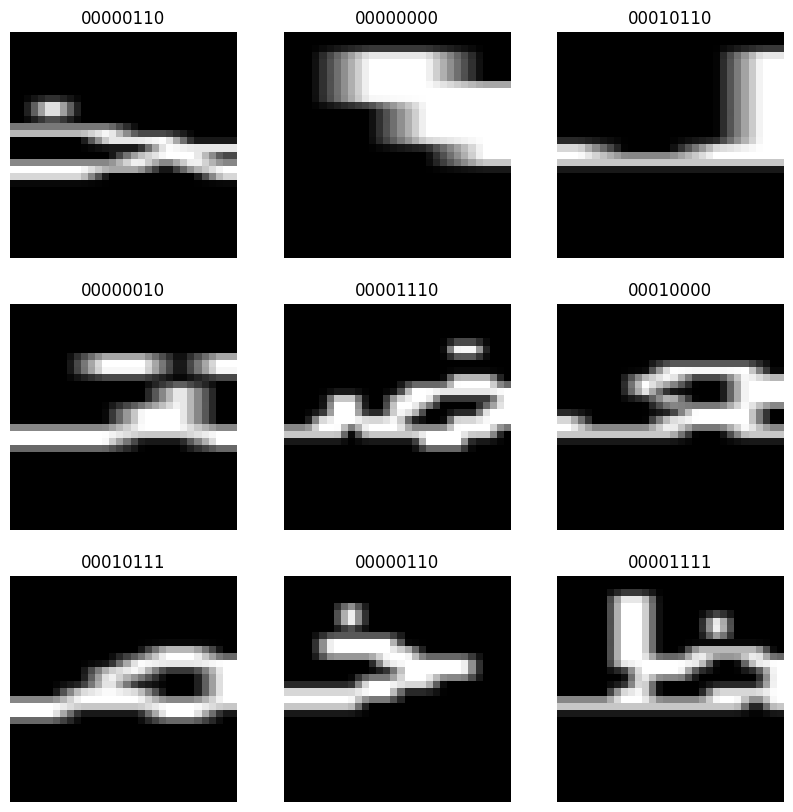

In [ ]:
plt.figure(figsize=(10,10))
for i,v in enumerate(np.random.randint(0,len(Data),9)):
    plt.subplot(3,3,i+1)
    plt.imshow(Data[v],cmap="gray")
    plt.title(Data_y[v])
    plt.axis('off')

# Split Data Train Test Val

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(Data, Data_y, test_size=0.2, random_state=42)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

In [ ]:
print(len(X_train) , len(X_test),len(X_val))

43175 14392 14392


In [ ]:
X_train[3].shape

(32, 32)

# Convert Data to np.array

In [ ]:
X_train=np.array(X_train)
y_train=np.array(y_train)

X_val=np.array(X_val)
y_val=np.array(y_val)


In [ ]:
X_test=np.array(X_test)
y_test=np.array(y_test)



```
# This is formatted as code
```

# **Defining The Required Functions**

# Function of Predicting and Evaluating a model

In [ ]:
def Model_Eval(model_n):

    y_probs_n=model_n.predict(X_test)
    y_pred_n=y_probs_n.argmax(axis=1)
    y_percent_n=np.amax(y_probs_n,axis=1)

    loss_n,accuracy_n=model_n.evaluate(X_val,y_val)
    print(f'validation loss= {loss_n}')
    print(f'validation accuracy= {accuracy_n}')

    accuracy_e_n=accuracy_score(y_test,y_pred_n)
    print(f'predictiong accuracy= {accuracy_e_n}')

# Visualize and  Plot of The Predicted Results

# Evaluation and Results Togther

In [ ]:
def Plot_Eval_Model_Pred(model_n):
    y_probs_n = model_n.predict(X_test)
    y_pred_n = y_probs_n.argmax(axis=1)  # Get predicted numerical labels
    y_percent_n = np.amax(y_probs_n, axis=1)

    # Assuming label_mapping is defined earlier
    y_test_numeric = np.array([label_mapping[label] for label in y_test])  # Convert y_test to numerical labels

    loss_n, accuracy_n = model_n.evaluate(X_val, y_val_numeric)
    print(f'validation loss= {loss_n}')
    print(f'validation accuracy= {accuracy_n}')

    # Calculate accuracy using numerical labels
    accuracy_e_n = accuracy_score(y_test_numeric, y_pred_n)
    print(f'predictiong accuracy= {accuracy_e_n}')

    plt.figure(figsize=(10, 9))
    plotnumber = 1

    # Create a reverse mapping from numerical indices to binary representations
    reverse_label_mapping = {v: k for k, v in label_mapping.items()}

    for i in range(1, 31):
        if plotnumber <= 30:
            ax = plt.subplot(5, 6, plotnumber)
            plt.imshow(X_test[i], cmap='gray')
            plt.axis('off')

            # Get binary representations for predicted and true labels
            predicted_binary = reverse_label_mapping[y_pred_n[i]]
            true_binary = y_test[i]  # y_test already contains binary representations

            plt.title(f'Pred: {predicted_binary} {round(y_percent_n[i] * 100)}% (True: {true_binary})',
                      fontdict={'fontsize': 10, 'color': ('green' if predicted_binary == true_binary else 'red')})
            plotnumber += 1
    plt.tight_layout()
    plt.show()

# Testing Model with One Image

In [ ]:
def Model_Pred_One_Img(model_n,path):
    img_1=cv2.imread(path,0)
    img_1=cv2.resize(img_1,(32,32))
    img_1=np.array(img_1)
    img_1_3d=img_1.reshape((1, 32, 32))
    img_1_prob=model_n.predict(np.array(img_1_3d))
    img_1_pred=img_1_prob.argmax(axis=1)
    plt.imshow(img_1,cmap='gray')
    plt.axis('off')
    predicted_binary = list(Binarycode.values())[img_1_pred[0]]
    name_1=getname(predicted_binary)
    Binary_representation=Binarycode.get(name_1)
    #print(name_1)
    print(Binary_representation)

# **Model Creation**

In [ ]:
from tensorflow import keras
import tensorflow as tf

model = keras.models.Sequential([
    keras.layers.Conv2D(filters=128, kernel_size=(8, 8), strides=(3, 3), activation='relu', input_shape=(32, 32, 1)),
    keras.layers.BatchNormalization(),

    keras.layers.Conv2D(filters=256, kernel_size=(5, 5), strides=(1, 1), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(pool_size=(2, 2)),

    keras.layers.Conv2D(filters=256, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=256, kernel_size=(1, 1), strides=(1, 1), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=256, kernel_size=(1, 1), strides=(1, 1), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),

    keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),

    keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),

    keras.layers.MaxPool2D(pool_size=(2, 2)),

    keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),

    keras.layers.MaxPool2D(pool_size=(2, 2)),

    keras.layers.Flatten(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(29, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.optimizers.SGD(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 9, 9, 128)      │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 9, 9, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 9, 9, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 9, 9, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 256)      │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 256)      │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 2, 2, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       525,31

 Total params: 9,064,605 (34.58 MB)

 Trainable params: 9,059,229 (34.56 MB)

 Non-trainable params: 5,376 (21.00 KB)

## Training Model

In [ ]:
# Assuming 'code' is defined as in your original code
# Create a mapping from characters to numerical indices
label_mapping = {v: i for i, v in enumerate(Binarycode.values())}

# Convert y_train and y_val to numerical labels using the mapping
y_train_numeric = np.array([label_mapping[label] for label in y_train])
y_val_numeric = np.array([label_mapping[label] for label in y_val])

# Now, fit the model using the numerical labels
es = EarlyStopping(monitor='val_loss', mode='min', patience=3)
history = model.fit(
    X_train,
    y_train_numeric,  # Use numerical labels
    epochs=5,
    batch_size=16,
    verbose=1,
    validation_data=(X_val, y_val_numeric),  # Use numerical labels
    callbacks=es
)

Epoch 1/5
2699/2699 ━━━━━━━━━━━━━━━━━━━━ 2069s 765ms/step - accuracy: 0.5303 - loss: 1.7800 - val_accuracy: 0.9728 - val_loss: 0.1091
Epoch 2/5
2060/2699 ━━━━━━━━━━━━━━━━━━━━ 7:54 743ms/step - accuracy: 0.9412 - loss: 0.2096

In [ ]:
model.save("/content/ auto-extra-mes-c.keras")

# **Model accuracy**

450/450 ━━━━━━━━━━━━━━━━━━━━ 88s 194ms/step
450/450 ━━━━━━━━━━━━━━━━━━━━ 88s 196ms/step - accuracy: 0.9939 - loss: 0.0239
validation loss= 0.023044535890221596
validation accuracy= 0.9945803284645081
predictiong accuracy= 0.995414118954975


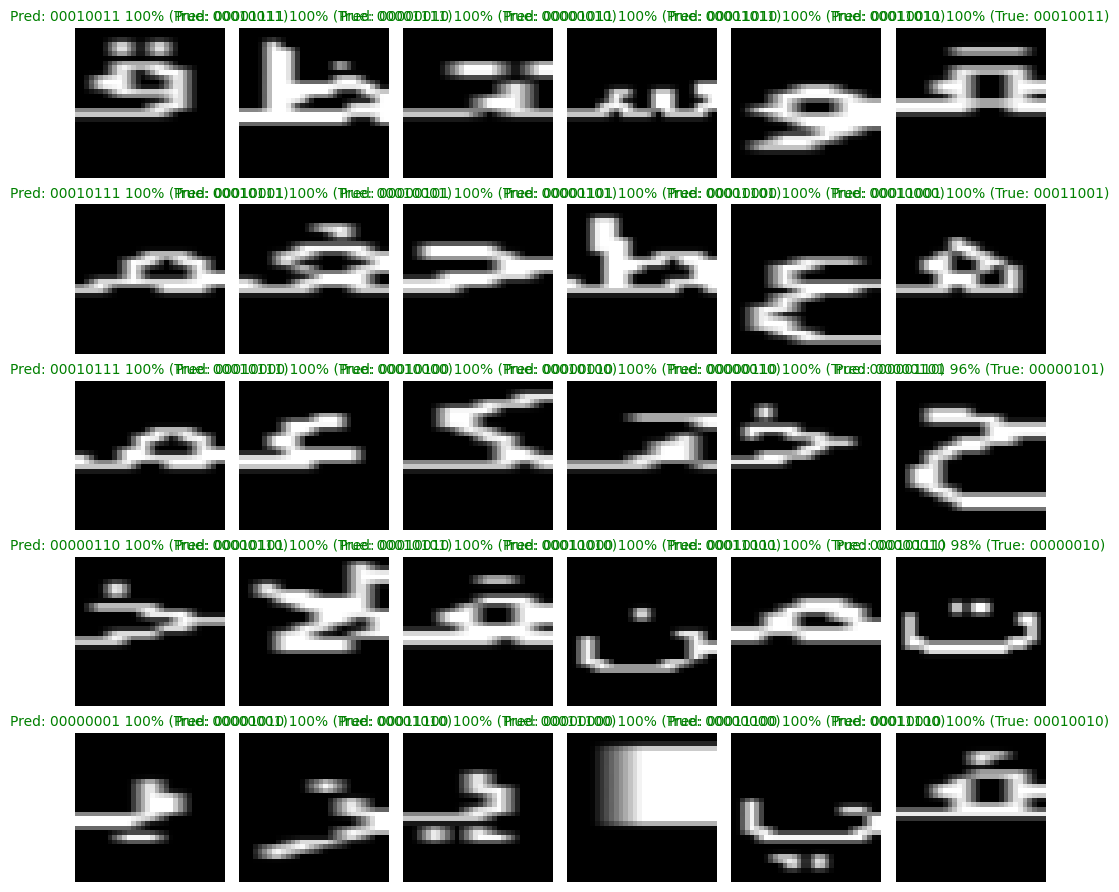

In [ ]:
Plot_Eval_Model_Pred(model)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 9, 9, 128)      │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 9, 9, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 9, 9, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 9, 9, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 256)      │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 256)      │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 2, 2, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       525,31

 Total params: 9,064,607 (34.58 MB)

 Trainable params: 9,059,229 (34.56 MB)

 Non-trainable params: 5,376 (21.00 KB)

 Optimizer params: 2 (12.00 B)

In [ ]:
model.save(" Auto-Extra-Mess.keras")

In [ ]:
from sklearn.metrics import accuracy_score

pred = model.predict(X_test)
pred = np.argmax(pred, axis=1)  # Pick class with highest probability

# Map predicted indices to binary representations using the 'code' dictionary
pred_binary = [list(Binarycode.keys())[idx] for idx in pred]  # code is your dictionary mapping characters to binary strings

# Calculate and print the accuracy
accuracy = accuracy_score(y_test, pred_binary)  # Assuming y_test contains the true binary representations
print(f"Accuracy: {accuracy}")

# Print the predicted and true binary representations for comparison (optional)
for i in range(len(pred_binary)):
    print(f"Predicted: {pred_binary[i]}, True: {y_test[i]}")

Streaming output truncated to the last 5000 lines.
Predicted: ذ, True: 00001000
Predicted: و, True: 00011010
Predicted: ع, True: 00010000
Predicted: ث, True: 00000011
Predicted: ر, True: 00001001
Predicted: ق, True: 00010011
Predicted: ج, True: 00000100
Predicted: ه, True: 00011001
Predicted: ت, True: 00000010
Predicted: م, True: 00010111
Predicted: ز, True: 00001010
Predicted: س, True: 00001011
Predicted: ظ, True: 00001111
Predicted: د, True: 00000111
Predicted: ج, True: 00000100
Predicted: ل, True: 00010110
Predicted: ه, True: 00011001
Predicted: ع, True: 00010000
Predicted: ي, True: 00011100
Predicted: س, True: 00001011
Predicted: ا, True: 00000000
Predicted: خ, True: 00000110
Predicted: ل, True: 00010110
Predicted: ج, True: 00000100
Predicted: ل, True: 00010110
Predicted: ق, True: 00010011
Predicted: ه, True: 00011001
Predicted: و, True: 00011010
Predicted: ط, True: 00001101
Predicted: ا, True: 00000000
Predicted: ر, True: 00001001
Predicted: ذ, True: 00001000
Predicted: ا, True: 0

In [ ]:
# plt.plot(history.history['accuracy'])
# plt.plot(history.history['val_accuracy'])
# plt.title('model accuracy')
# plt.ylabel('accuracy')
# plt.xlabel('epoch')
# plt.legend(['train', 'val'], loc='upper left')

# # Get the final accuracy scores
# train_accuracy = history.history['accuracy'][-1]
# val_accuracy = history.history['val_accuracy'][-1]

# # Add text annotations to the plot
# plt.text(len(history.history['accuracy']) - 1, train_accuracy, f'{train_accuracy:.4f}', color='blue', ha='right', va='bottom')
# plt.text(len(history.history['val_accuracy']) - 1, val_accuracy, f'{val_accuracy:.4f}', color='orange', ha='right', va='bottom')

# plt.show()

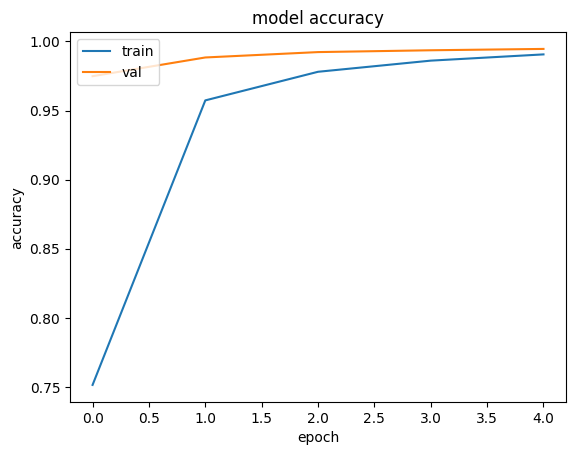

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

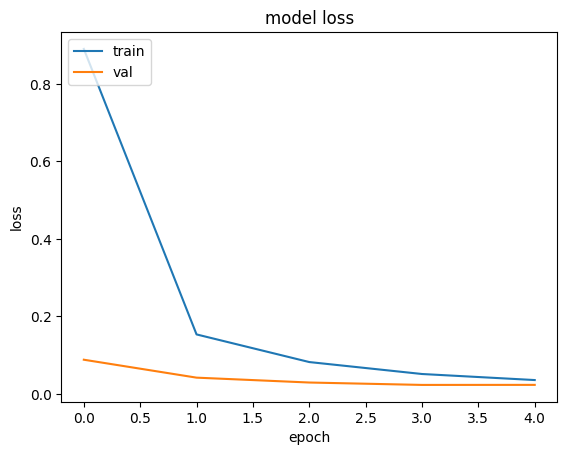

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# Accuracy, Precision, Recall, Time Savings

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

def calculate_metrics(model, X_test, y_test, Binarycode):
    """Calculates precision, recall, and F1-score."""

    # Get prediction probabilities
    y_probs = model.predict(X_test)

    # Get predicted class indices (without threshold)
    y_pred_indices = np.argmax(y_probs, axis=1)

    # Assuming y_test already contains the true binary representations
    # Convert y_test to numerical indices for metric calculations
    label_mapping = {v: i for i, v in enumerate(Binarycode.values())}
    y_test_numeric = np.array([label_mapping[label] for label in y_test])

    # Calculate precision, recall, and F1-score using numerical indices
    precision = precision_score(y_test_numeric, y_pred_indices, average='weighted')
    recall = recall_score(y_test_numeric, y_pred_indices, average='weighted')
    f1 = f1_score(y_test_numeric, y_pred_indices, average='weighted')

    return precision, recall, f1

# ... (Your existing code where you load the model and have X_test, y_test, Binarycode) ...

# # Calculate metrics (without threshold)
# precision, recall, f1 = calculate_metrics(model, X_test, y_test, Binarycode)
# print(f"Precision: {precision}, Recall: {recall}, F1-score: {f1}")

In [ ]:
# Get prediction probabilities instead of class labels
y_probs = model.predict(X_test)

# Adjust threshold for positive predictions
threshold = 0.3  # Example threshold value
y_pred_adjusted = (y_probs >= threshold).astype(int)

# Calculate metrics with adjusted predictions
precision, recall, f1 = calculate_metrics(model, X_test, y_test, Binarycode)
print(f"Precision:{precision},recall: {recall},f1:{f1}")

450/450 ━━━━━━━━━━━━━━━━━━━━ 102s 227ms/step
450/450 ━━━━━━━━━━━━━━━━━━━━ 87s 192ms/step
Precision:0.9954534026694084,recall: 0.995414118954975,f1:0.9954150106124586


In [ ]:
model = load_model('/content/_Last agin with original and emails.keras')

In [ ]:
# def getname(n):
#     for k,v in Binarycode.items():
#         if v==n:
#             return k

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
00010111


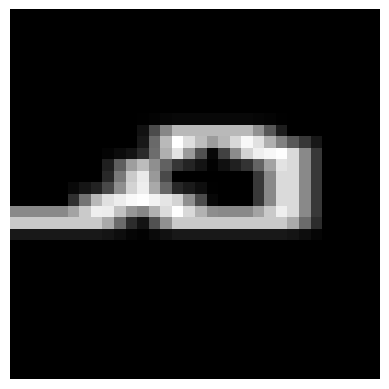

In [ ]:
Model_Pred_One_Img(model,'/content/sample_data/17.png')

In [ ]:
# image_path = '/content/2.png'  # Replace with the path to your image
# import matplotlib.pyplot as plt
# img = cv2.imread(image_path, 0)
# plt.imshow(img, cmap='gray')
# plt.show()
# binary_representation = pred_one_img(model, image_path)
# print(binary_representation)

## Segmentaion to extract letters and predict their binary representations.

In [ ]:
def process_image(image_path):

    image = cv2.imread(image_path, 0)
    _, thresholded = cv2.threshold(image, 125, 255, cv2.THRESH_BINARY_INV)
    contours, _ = cv2.findContours(thresholded, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    binary_representation_result = ''
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        if w > 10 and h > 10:
            letter = image[y:y + h, x:x + w]
            resized_letter = cv2.resize(letter, (32, 32))
            resized_letter = resized_letter.reshape(1, 32, 32)  # Reshape for prediction

            # Prediction using pred_one_img logic
            img_prob = model.predict(np.array(resized_letter))
            img_pred = img_prob.argmax(axis=1)
            predicted_binary = list(Binarycode.values())[img_pred[0]]
            char_name = getname(predicted_binary)  # Get character name

            if char_name:
                binary_representation_result += Binarycode.get(char_name, '')  # Get binary representation

    return binary_representation_result

In [ ]:
# Example usage:
image_path = '/content/sample_data/test.png'  # Replace with the path to your image
binary_representation_of_word = process_image(image_path)
print(f"Binary representation of the word: {binary_representation_of_word}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
Binary representation of the word: 000101100001011000011100


In [ ]:
# def process_word_image(image_path):
#     """Processes an image containing a word, performs segmentation, and returns the binary representation."""

#     binary_representation = process_image(image_path)
#     return binary_representation

In [ ]:
def process_imagee(image_path):
    image = cv2.imread(image_path, 0)
    _, thresholded = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY_INV)

    # Assuming letters are horizontally aligned, sum pixel values along columns
    col_sums = np.sum(thresholded, axis=0)

    # Find columns with mostly white pixels (potential letter boundaries)
    letter_cols = np.where(col_sums > np.mean(col_sums) + np.std(col_sums))[0]

    # Check if letter_cols is empty before accessing elements
    if len(letter_cols) == 0:
        print("No letter boundaries found in the image. Adjust threshold or image processing.")
        return ''  # Return empty string if no letter boundaries are found

    # Split the image into letters using letter boundaries
    letters = []
    start_col = letter_cols[0]
    for i in range(1, len(letter_cols)):
        if letter_cols[i] - letter_cols[i - 1] > 15:  # Adjust threshold as needed
            letters.append(image[:, start_col:letter_cols[i - 1]])  # Extract letter
            start_col = letter_cols[i]
    letters.append(image[:, start_col:letter_cols[-1]])  # Extract last letter

    binary_representation_result = ''
    for letter in letters:
        # Resize and reshape the letter image for prediction
        letter_image = cv2.resize(letter, (32, 32))
        letter_image = letter_image.reshape(1, 32, 32)

        # Make prediction
        prediction = model.predict(letter_image)
        predicted_class_index = np.argmax(prediction)

        # Get the binary representation from the predicted class index
        predicted_binary = list(Binarycode.values())[predicted_class_index]
        binary_representation_result += predicted_binary

    return binary_representation_result

### Confidance Interval

In [ ]:
import math
from scipy import stats

# Accuracy from previous calculations
accuracy = 0.995414118954975
# Number of test samples
n_samples = len(X_test)

# Calculate standard error of the proportion
std_error = math.sqrt((accuracy * (1 - accuracy)) / n_samples)

# For a 95% confidence interval, the Z-score is approximately 1.96
z_score = stats.norm.ppf(0.975)  # Z-score for 95% confidence (two-tailed)

# Calculate the margin of error
margin_of_error = z_score * std_error

# Calculate the confidence interval
confidence_interval_lower = accuracy - margin_of_error
confidence_interval_upper = accuracy + margin_of_error

print(f"Accuracy: {accuracy:.4f}")
print(f"Number of test samples: {n_samples}")
print(f"Standard Error: {std_error:.4f}")
print(f"Margin of Error (95% CI): {margin_of_error:.4f}")
print(f"95% Confidence Interval: [{confidence_interval_lower:.4f}, {confidence_interval_upper:.4f}]")
print(f"Error Bar for Accuracy: +/- {margin_of_error:.4f}")

Accuracy: 0.9954
Number of test samples: 14392
Standard Error: 0.0006
Margin of Error (95% CI): 0.0011
95% Confidence Interval: [0.9943, 0.9965]
Error Bar for Accuracy: +/- 0.0011
